# Case Study : Card Shuffling 

ORIGINAL DECK

ace of hearts      2 of hearts        3 of hearts        4 of hearts        
5 of hearts        6 of hearts        7 of hearts        8 of hearts        
9 of hearts        10 of hearts       jack of hearts     queen of hearts    
king of hearts     ace of diamonds    2 of diamonds      3 of diamonds      
4 of diamonds      5 of diamonds      6 of diamonds      7 of diamonds      
8 of diamonds      9 of diamonds      10 of diamonds     jack of diamonds   
queen of diamonds  king of diamonds   ace of clubs       2 of clubs         
3 of clubs         4 of clubs         5 of clubs         6 of clubs         
7 of clubs         8 of clubs         9 of clubs         10 of clubs        
jack of clubs      queen of clubs     king of clubs      ace of spades      
2 of spades        3 of spades        4 of spades        5 of spades        
6 of spades        7 of spades        8 of spades        9 of spades        
10 of spades       jack of spades     queen of spades    king

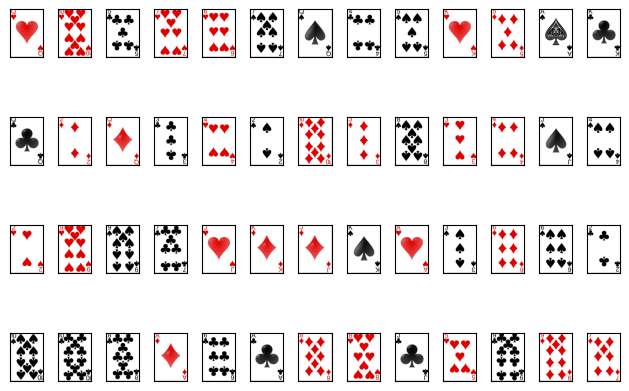

In [3]:


import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


# ---------------------------------------------
# Card Class
# ---------------------------------------------
class Card:
    # Class attributes (shared by all cards)
    FACES = ['ace', '2', '3', '4', '5', '6',
             '7', '8', '9', '10', 'jack', 'queen', 'king']

    SUITS = ['hearts', 'diamonds', 'clubs', 'spades']

    def __init__(self, face, suit):
        self._face = face
        self._suit = suit

    @property
    def face(self):
        return self._face

    @property
    def suit(self):
Untitled.ipynb
Feb_5_OOPBasics.ipynb
Feb_19_ContinuingWithOOPS.ipynb
Untitled.ipynb
Untitled.ipynb
Untitled.ipynb
Untitled1.ipynb
Untitled1.ipynb
Untitled.ipynb
Untitled.ipynb
￼
￼
￼
￼
￼

        return self._suit

    @property
    def image_name(self):
        return str(self).replace(' ', '_') + '.png'

    def __repr__(self):
        return f"Card(face='{self.face}', suit='{self.suit}')"

    def __str__(self):
        return f"{self.face} of {self.suit}"

    def __format__(self, format_spec):
        return f"{str(self):{format_spec}}"


# ---------------------------------------------
# DeckOfCards Class
# ---------------------------------------------
class DeckOfCards:
    NUMBER_OF_CARDS = 52

    def __init__(self):
        self._current_card = 0
        self._deck = []

        # Create 52 cards in order
        for count in range(DeckOfCards.NUMBER_OF_CARDS):
            self._deck.append(
                Card(Card.FACES[count % 13],
                     Card.SUITS[count // 13])
            )

    def shuffle(self):
        self._current_card = 0
        random.shuffle(self._deck)

    def deal_card(self):
        try:
            card = self._deck[self._current_card]
            self._current_card += 1
            return card
        except IndexError:
            return None

    def __str__(self):
        s = ''
        for index, card in enumerate(self._deck):
            s += f"{card:<19}"
            if (index + 1) % 4 == 0:
                s += '\n'
        return s


# ---------------------------------------------
# Main Program
# ---------------------------------------------
if __name__ == "__main__":

    # Create deck
    deck_of_cards = DeckOfCards()

    print("ORIGINAL DECK\n")
    print(deck_of_cards)

    # Shuffle deck
    deck_of_cards.shuffle()
    print("\nSHUFFLED DECK\n")
    print(deck_of_cards)

    # Deal 5 cards
    print("\nDEALING 5 CARDS")
    for _ in range(5):
        print(deck_of_cards.deal_card())

    # -------------------------------------------------
    # OPTIONAL: Display Card Images (requires images)
    # -------------------------------------------------
    """
    Make sure:
    - You have a folder named 'card_images'
    - It contains 52 PNG files
    - Names like: Ace_of_Hearts.png, 10_of_Spades.png etc.
    """

    try:
        print("\nDisplaying card images...")

        deck_of_cards.shuffle()

        path = Path('.').joinpath('Playing_Cards')
        figure, axes_list = plt.subplots(nrows=4, ncols=13)

        for axes in axes_list.ravel():
            axes.get_xaxis().set_visible(False)
            axes.get_yaxis().set_visible(False)

            card = deck_of_cards.deal_card()
            image_name = card.image_name

            img = mpimg.imread(str(path.joinpath(image_name).resolve()))
            axes.imshow(img)

        figure.tight_layout()
        plt.show()

    except Exception as e:
        print("\nImage display skipped (card_images folder not found).")
        print("Error:", e)
